# Fast-Text Models
Objective: Evaluate using fastText as a baseline text classifier both with and without hyperparameter optimization

In [3]:
import pandas as pd
import numpy as np

# Model
import fasttext #uv pip install fasttext-wheel

import sys
sys.path.append("../utils")

from evaluate_models import plot_confusion_matrix, print_evaluation_report

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)

## Load and Prepare the Data

In [4]:
# Load the data
train = pd.read_parquet("../01 - Inputs/train_data.parquet")
validation = pd.read_parquet("../01 - Inputs/val_data.parquet")
test = pd.read_parquet("../01 - Inputs/test_data.parquet")

train_validation = pd.concat([train, validation], ignore_index=True) # Concat for the baseline no-tuning model

In [5]:
# Reformat the data for fasttext
# Fasttext expects the data to be in the format: __label__<label> <text>
def reformat_for_fasttext(df):
    df["text"] = "__label__" + df["Character"].astype(str).str.replace(" ", "_") + " " + df["Line"]
    return df[["text"]]

train_fasttext = reformat_for_fasttext(train)
validation_fasttext = reformat_for_fasttext(validation)
train_validation_fasttext = reformat_for_fasttext(train_validation)
test_fasttext = reformat_for_fasttext(test)

# Save the reformatted data to text files
train_fasttext.to_csv("../01 - Inputs/train_fasttext.txt", index=False, header=False)
validation_fasttext.to_csv("../01 - Inputs/validation_fasttext.txt", index=False, header=False)
train_validation_fasttext.to_csv("../01 - Inputs/train_validation_fasttext.txt", index=False, header=False)

## Models

### Default Fasttext Model

In [6]:
# Train the model
baseline_model = fasttext.train_supervised("../01 - Inputs/train_validation_fasttext.txt")

In [7]:
# Make predictions on the test set
test_predictions_baseline = baseline_model.predict(test_fasttext["text"].tolist())

In [8]:
test['predicted_baseline'] = pd.Series(np.array(test_predictions_baseline[0]).flatten()).str.replace("__label__", "").str.replace("_", " ")

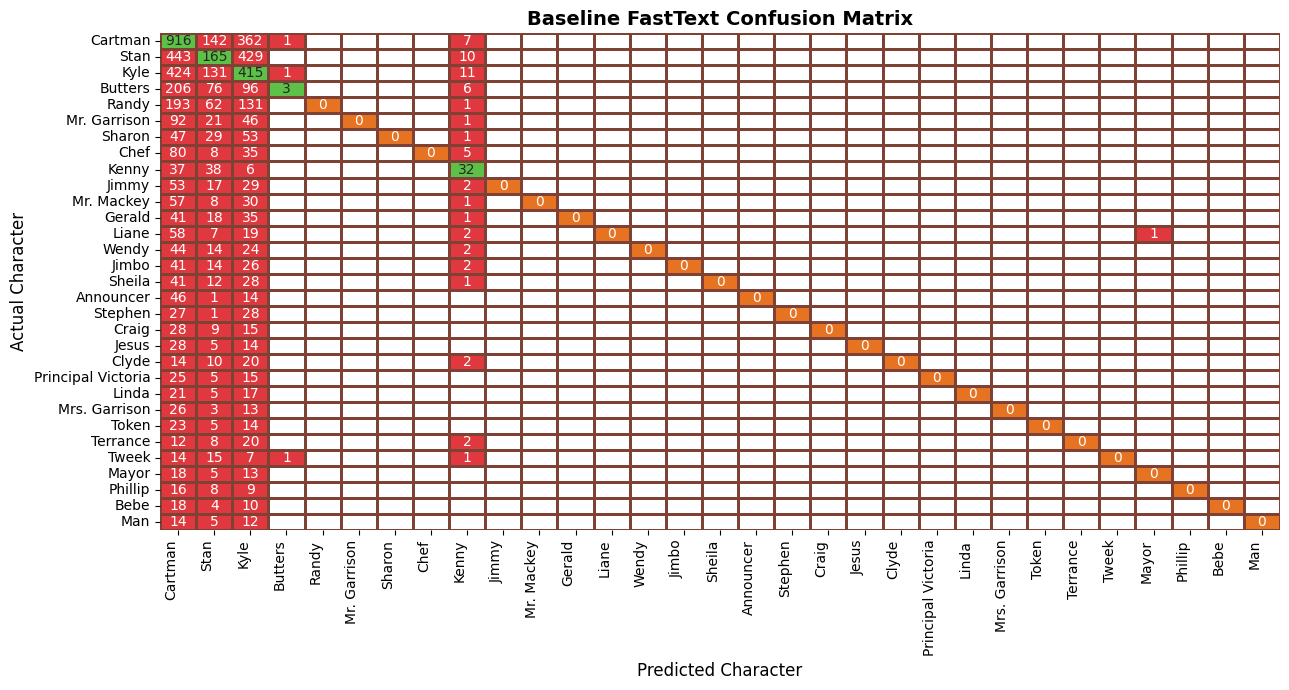

In [9]:
plot_confusion_matrix(
    y_true=test["Character"].values,
    y_pred=test["predicted_baseline"].values,
    title="Baseline FastText Confusion Matrix",
    save_path="../05 - Outputs/baseline_fasttext_confusion_matrix.png",
    figsize=(13, 7),
)

In [10]:
metrics_baseline = {
        'accuracy': accuracy_score(test['Character'], test['predicted_baseline']),
        'precision': precision_score(test['Character'], test['predicted_baseline'], average='macro', zero_division=0),
        'recall': recall_score(test['Character'], test['predicted_baseline'], average='macro', zero_division=0),
        'f1_score': f1_score(test['Character'], test['predicted_baseline'], average='macro', zero_division=0)
    }
print_evaluation_report(metrics_baseline, "Baseline FastText")


Baseline FastText Evaluation Results
Accuracy:  0.2536
Precision: 0.0501 (macro)
Recall:    0.0488 (macro)
F1-Score:  0.0383 (macro)



### FastText Baseline with Hierarchical Softmax
According to the [sources](https://stats.stackexchange.com/a/386293), hierarchical softmax is a good choice for class imbalance. Let's see if it improves our results.

In [11]:
# Train model with hs
model_hs = fasttext.train_supervised("../01 - Inputs/train_validation_fasttext.txt", loss='hs')

# Make predictions on the test set
test_predictions_hs = model_hs.predict(test_fasttext["text"].tolist())
test['predicted_hs'] = pd.Series(np.array(test_predictions_hs[0]).flatten()).str.replace("__label__", "").str.replace("_", " ")

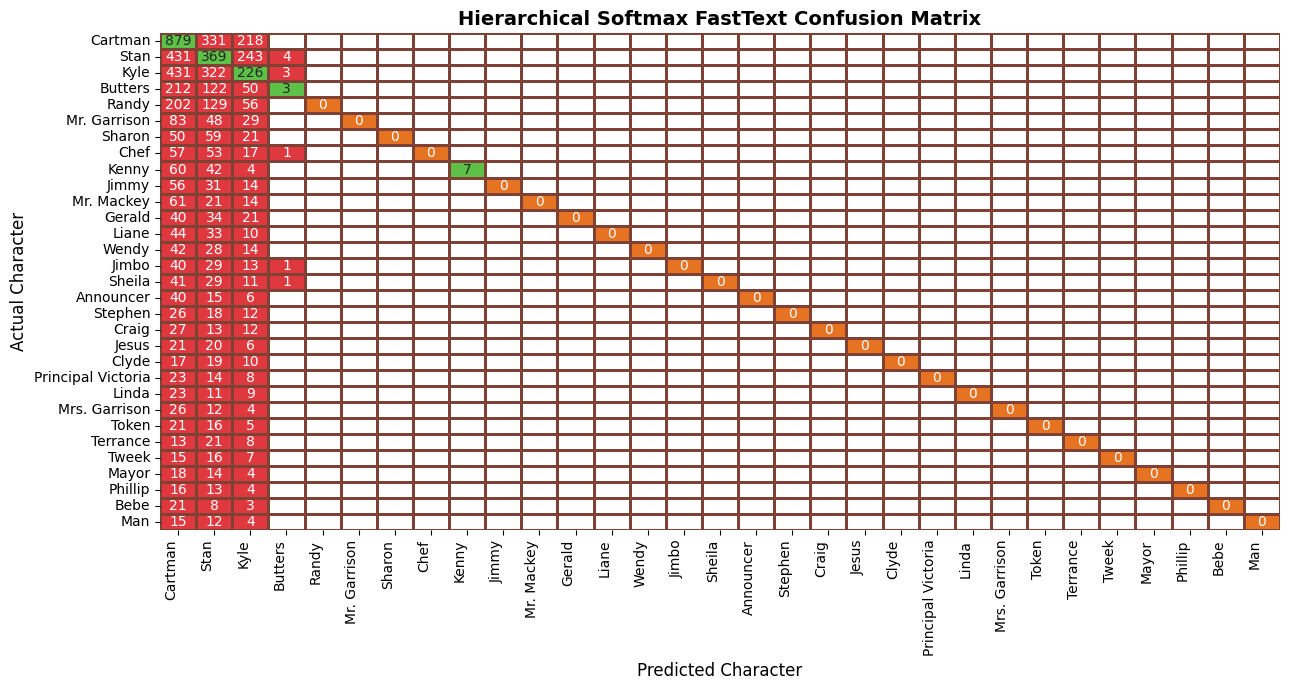

In [12]:
plot_confusion_matrix(
    y_true=test["Character"],
    y_pred=test["predicted_hs"],
    title="Hierarchical Softmax FastText Confusion Matrix",
    save_path="../05 - Outputs/hs_fasttext_confusion_matrix.png",
    figsize=(13, 7),
)

In [14]:
metrics_hs = {
        'accuracy': accuracy_score(test['Character'], test['predicted_hs']),
        'precision': precision_score(test['Character'], test['predicted_hs'], average='macro', zero_division=0),
        'recall': recall_score(test['Character'], test['predicted_hs'], average='macro', zero_division=0),
        'f1_score': f1_score(test['Character'], test['predicted_hs'], average='macro', zero_division=0)
    }
print_evaluation_report(metrics_hs, "Hierarchical Softmax FastText")


Hierarchical Softmax FastText Evaluation Results
Accuracy:  0.2459
Precision: 0.0621 (macro)
Recall:    0.0409 (macro)
F1-Score:  0.0321 (macro)



### FastText Hyperparameter Tuning
We will use the built-in hyperparameter tuning as referenced in the [documentation](https://fasttext.cc/docs/en/autotune.html)

In [15]:
# We'll need to use separated train and validation sets for autotuning
TUNE_TIME = 10 # minutes
tuned_model = fasttext.train_supervised(input='../01 - Inputs/train_fasttext.txt', autotuneValidationFile='../01 - Inputs/validation_fasttext.txt', autotuneDuration=TUNE_TIME * 60)

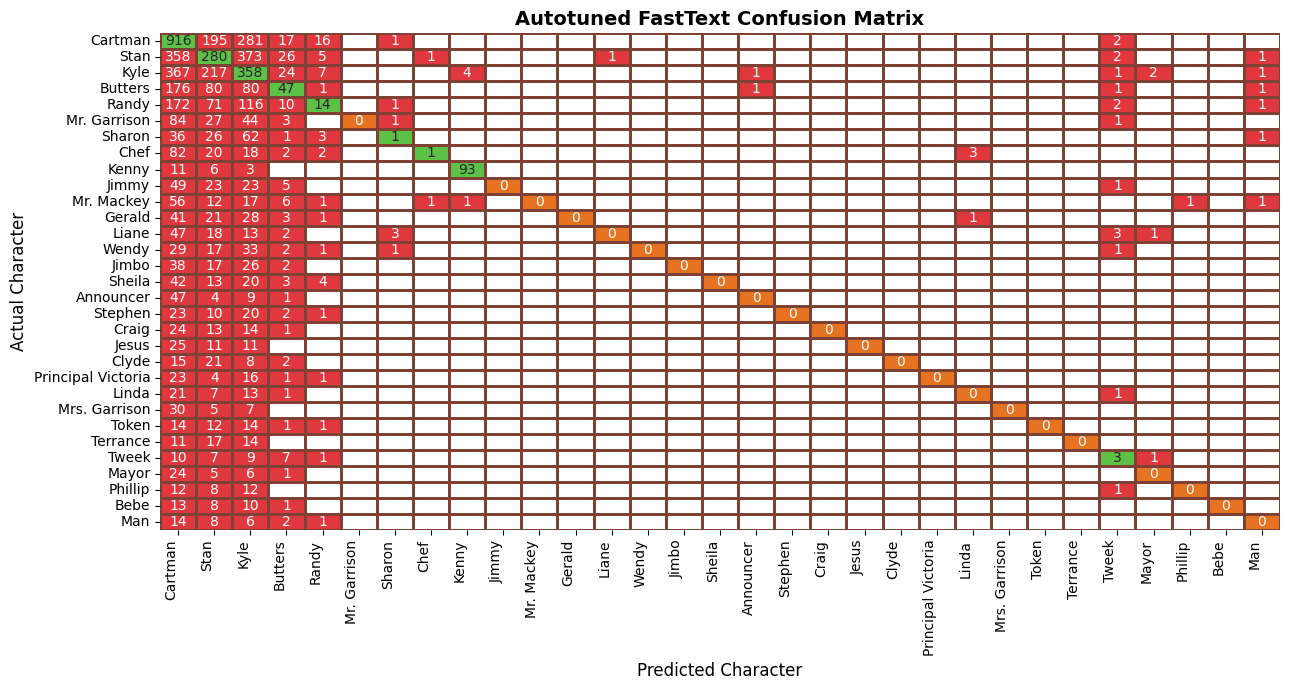

In [16]:
# Get predictions
test_predictions_tuned = tuned_model.predict(test_fasttext["text"].tolist())
test['predicted_tuned'] = pd.Series(np.array(test_predictions_tuned[0]).flatten()).str.replace("__label__", "").str.replace("_", " ")
plot_confusion_matrix(
    y_true=test["Character"],
    y_pred=test["predicted_tuned"],
    title="Autotuned FastText Confusion Matrix",
    save_path="../05 - Outputs/autotuned_fasttext_confusion_matrix.png",
    figsize=(13, 7),
)

In [17]:
metrics_tuned = {
        'accuracy': accuracy_score(test['Character'], test['predicted_tuned']),
        'precision': precision_score(test['Character'], test['predicted_tuned'], average='macro', zero_division=0),
        'recall': recall_score(test['Character'], test['predicted_tuned'], average='macro', zero_division=0),
        'f1_score': f1_score(test['Character'], test['predicted_tuned'], average='macro', zero_division=0)
    }
print_evaluation_report(metrics_tuned, "Autotuned FastText")


Autotuned FastText Evaluation Results
Accuracy:  0.2838
Precision: 0.0919 (macro)
Recall:    0.0758 (macro)
F1-Score:  0.0710 (macro)



## Combine Results and Output

In [19]:
all_metrics = pd.DataFrame([metrics_baseline, metrics_hs, metrics_tuned], index=["Baseline FastText", "Hierarchical Softmax FastText", "Autotuned FastText"])
all_metrics.to_csv("../05 - Outputs/fasttext_metrics_comparison.csv")